In [18]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random
import copy
import os

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import StepLR

from torch_geometric.data import HeteroData
from torch_geometric.nn import GATv2Conv, Linear

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

Using device: cuda
GPU: NVIDIA GeForce RTX 3050


In [19]:
# ## 2. Load Data and Define Feature Columns

# %%
tcga_df = pd.read_csv('../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 
                'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 
                'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']

print("Data loaded.")
print("TCGA shape:", tcga_df.shape)
print("CGGA shape:", cgga_df.shape)

Data loaded.
TCGA shape: (839, 24)
CGGA shape: (286, 24)


In [22]:
# First split: separate training (80%) and test (20%)
train_df, test_df = train_test_split(
    tcga_df, 
    test_size=0.2, 
    stratify=tcga_df['Grade'], 
    random_state=42
)

print("After first split (80% train / 20% test):")
print(f"  Intermediate train size: {len(train_df)}")
print(f"  Test size: {len(test_df)}")
print("  Train class distribution:")
print(train_df['Grade'].value_counts())
print()

# Second split: further split the training data into final train (80% of train) and validation (20% of train)
train_df, val_df = train_test_split(
    train_df, 
    test_size=0.2, 
    stratify=train_df['Grade'], 
    random_state=42
)

print("After inner split (80% of train / 20% of train):")
print(f"  Final train size: {len(train_df)}")
print(f"  Validation size: {len(val_df)}")
print("  Final train class distribution (before balancing):")
print(train_df['Grade'].value_counts())
print()
print(f"Total patients accounted for: {len(train_df) + len(val_df) + len(test_df)}")

After first split (80% train / 20% test):
  Intermediate train size: 671
  Test size: 168
  Train class distribution:
Grade
0    389
1    282
Name: count, dtype: int64

After inner split (80% of train / 20% of train):
  Final train size: 536
  Validation size: 135
  Final train class distribution (before balancing):
Grade
0    311
1    225
Name: count, dtype: int64

Total patients accounted for: 839


Generating 86 synthetic minority samples for training...


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 573.72it/s]


Original training class counts: {0: 311, 1: 225}
Synthetic samples added: 86
Balanced training class counts: {0: 311, 1: 311}


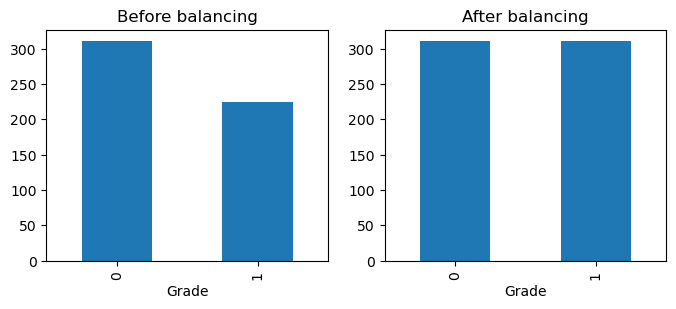

In [23]:
# 4. Balance ONLY the Final Training Set with CTGAN
# Metadata for CTGAN
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    metadata.update_column(column_name=col, sdtype='categorical')

# Determine how many minority samples to add
class_counts = train_df['Grade'].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
samples_needed = class_counts[majority_class] - class_counts[minority_class]

print(f"Generating {samples_needed} synthetic minority samples for training...")

# Fit CTGAN only on training data
synthesizer = CTGANSynthesizer(metadata, epochs=150, batch_size=50, verbose=False, cuda=True)
synthesizer.fit(train_df)

# Generate only minority-class samples
condition = Condition(num_rows=samples_needed, column_values={'Grade': minority_class})
synthetic_samples = synthesizer.sample_from_conditions(conditions=[condition])

# Create balanced training set
train_balanced_df = pd.concat([train_df, synthetic_samples], ignore_index=True)

print("Original training class counts:", train_df['Grade'].value_counts().to_dict())
print("Synthetic samples added:", len(synthetic_samples))
print("Balanced training class counts:", train_balanced_df['Grade'].value_counts().to_dict())

# Optional: quick bar plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2, figsize=(8,3))
train_df['Grade'].value_counts().plot(kind='bar', ax=axes[0], title='Before balancing')
train_balanced_df['Grade'].value_counts().plot(kind='bar', ax=axes[1], title='After balancing')
plt.show()  

In [24]:
# 5. Graph Construction Function (with reverse edges)

def construct_bipartite_heterograph(df):
    """Build a heterogeneous graph with Patient and Gene nodes, including reverse edges."""
    graph = HeteroData()
    
    # Patient features: Gender, Race, Age (normalized)
    scaler = StandardScaler()
    age_norm = scaler.fit_transform(df[['Age_at_diagnosis']])
    patient_feats = np.hstack([df[['Gender', 'Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(patient_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    
    # Gene nodes: one‑hot identity
    num_genes = len(gene_columns)
    graph['Gene'].x = torch.eye(num_genes, dtype=torch.float)
    
    # Edge lists (Gene -> Patient)
    src_genes, dst_patients = [], []
    # Use enumerate to get contiguous patient index 0..N-1
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx)
                dst_patients.append(p_idx)
    
    # Forward edges (Gene -> Patient)
    graph['Gene', 'mutates', 'Patient'].edge_index = torch.tensor([src_genes, dst_patients], dtype=torch.long)
    # Reverse edges (Patient -> Gene)
    graph['Patient', 'mutated_by', 'Gene'].edge_index = torch.tensor([dst_patients, src_genes], dtype=torch.long)
    
    return graph

In [25]:
# 6. Build Graphs for Train, Val, Test, and CGGA

# %%
tcga_train_graph = construct_bipartite_heterograph(train_balanced_df).to(device)
tcga_val_graph   = construct_bipartite_heterograph(val_df).to(device)
tcga_test_graph  = construct_bipartite_heterograph(test_df).to(device)
cgga_graph       = construct_bipartite_heterograph(cgga_df).to(device)

print("Graphs built and moved to device.")
print(f"Train patients: {tcga_train_graph['Patient'].x.shape[0]}")
print(f"Val patients:   {tcga_val_graph['Patient'].x.shape[0]}")
print(f"Test patients:  {tcga_test_graph['Patient'].x.shape[0]}")
print(f"CGGA patients:  {cgga_graph['Patient'].x.shape[0]}")


Graphs built and moved to device.
Train patients: 622
Val patients:   135
Test patients:  168
CGGA patients:  286


In [26]:
# 7. Define the GNN Model (Heterogeneous GATv2)

class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=8, dropout=0.5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        
        # Initial linear projections for each node type (lazy layers)
        self.patient_lin = Linear(-1, hidden_dim)
        self.gene_lin = Linear(-1, hidden_dim)
        
        # Relation‑specific GAT layers (we have two relations: mutates and mutated_by)
        self.conv_gene_to_patient = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.conv_patient_to_gene = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        
        # Skip connections
        self.patient_skip = Linear(hidden_dim, hidden_dim)
        self.gene_skip = Linear(hidden_dim, hidden_dim)
        
        # Final classifier (only on patient nodes)
        self.classifier = Linear(hidden_dim, out_dim)

    def forward(self, x_dict, edge_index_dict):
        # Initial transformation
        h_patient = F.relu(self.patient_lin(x_dict['Patient']))
        h_gene = F.relu(self.gene_lin(x_dict['Gene']))
        
        # Gene -> Patient message passing
        out_patient = self.conv_gene_to_patient((h_gene, h_patient), edge_index_dict[('Gene', 'mutates', 'Patient')])
        
        # Patient -> Gene message passing (reverse)
        out_gene = self.conv_patient_to_gene((h_patient, h_gene), edge_index_dict[('Patient', 'mutated_by', 'Gene')])
        
        # Skip connections
        h_patient = self.patient_skip(h_patient) + out_patient
        h_gene = self.gene_skip(h_gene) + out_gene
        
        # Activation and dropout
        h_patient = F.dropout(F.leaky_relu(h_patient, 0.2), self.dropout, training=self.training)
        h_gene = F.dropout(F.leaky_relu(h_gene, 0.2), self.dropout, training=self.training)
        
        # Return logits for patient nodes only
        return self.classifier(h_patient)

In [27]:
# 8. Loss Function (Focal Loss) and Class Weights

# %%
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# Class weights based on original training imbalance (before balancing)
original_counts = train_df['Grade'].value_counts()
majority = original_counts.idxmax()
minority = original_counts.idxmin()
penalty = original_counts[majority] / original_counts[minority]
class_weights = torch.tensor([1.0, penalty], dtype=torch.float).to(device)

criterion = FocalLoss(alpha=1, gamma=2, weight=class_weights)

In [28]:
# 9. Hyperparameter Tuning with Random Search

# %%
# Define search space
param_space = {
    'hidden_dim': [16, 32, 64],
    'num_heads': [4, 8],
    'dropout': [0.3, 0.5, 0.7],
    'lr': [0.001, 0.005, 0.01],
    'weight_decay': [1e-4, 5e-4]
}

n_trials = 20          
max_epochs = 200
patience = 20

def train_and_evaluate(params):
    """Train a model with given hyperparameters and return best validation AUC and model state."""
    model = HeteroGATv2(
        hidden_dim=params['hidden_dim'],
        out_dim=2,
        num_heads=params['num_heads'],
        dropout=params['dropout']
    ).to(device)

    # Dummy forward to initialize lazy layers
    with torch.no_grad():
        _ = model(tcga_train_graph.x_dict, tcga_train_graph.edge_index_dict)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

    best_val_auc = 0
    patience_counter = 0
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        out = model(tcga_train_graph.x_dict, tcga_train_graph.edge_index_dict)
        loss = criterion(out, tcga_train_graph['Patient'].y)
        loss.backward()
        optimizer.step()
        scheduler.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_out = model(tcga_val_graph.x_dict, tcga_val_graph.edge_index_dict)
            val_probs = F.softmax(val_out, dim=1)[:, 1].cpu().numpy()
            val_labels = tcga_val_graph['Patient'].y.cpu().numpy()
            val_auc = roc_auc_score(val_labels, val_probs)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_val_auc, best_model_state

# Perform random search
best_score = 0
best_params = None
best_state = None

print("Starting hyperparameter tuning...\n")
for trial in range(1, n_trials + 1):
    params = {
        'hidden_dim': random.choice(param_space['hidden_dim']),
        'num_heads': random.choice(param_space['num_heads']),
        'dropout': random.choice(param_space['dropout']),
        'lr': random.choice(param_space['lr']),
        'weight_decay': random.choice(param_space['weight_decay'])
    }
    print(f"Trial {trial}/{n_trials}: {params}")

    val_auc, model_state = train_and_evaluate(params)
    print(f"  Validation AUC: {val_auc:.4f}\n")

    if val_auc > best_score:
        best_score = val_auc
        best_params = params
        best_state = model_state

print("="*50)
print("Best hyperparameters found:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Best validation AUC: {best_score:.4f}")
print("="*50)

Starting hyperparameter tuning...

Trial 1/20: {'hidden_dim': 64, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.01, 'weight_decay': 0.0005}
  Validation AUC: 0.9296

Trial 2/20: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.01, 'weight_decay': 0.0001}
  Validation AUC: 0.9300

Trial 3/20: {'hidden_dim': 64, 'num_heads': 4, 'dropout': 0.7, 'lr': 0.005, 'weight_decay': 0.0001}
  Validation AUC: 0.9298

Trial 4/20: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001}
  Validation AUC: 0.9082

Trial 5/20: {'hidden_dim': 64, 'num_heads': 4, 'dropout': 0.7, 'lr': 0.01, 'weight_decay': 0.0005}
  Validation AUC: 0.9291

Trial 6/20: {'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.7, 'lr': 0.005, 'weight_decay': 0.0001}
  Validation AUC: 0.9359

Trial 7/20: {'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.5, 'lr': 0.005, 'weight_decay': 0.0001}
  Validation AUC: 0.9336

Trial 8/20: {'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.3, 'lr': 0.001, 'weight_de

In [29]:
# 10. Evaluate Best Model on Test Set and CGGA
# Build best model
best_model = HeteroGATv2(
    hidden_dim=best_params['hidden_dim'],
    out_dim=2,
    num_heads=best_params['num_heads'],
    dropout=best_params['dropout']
).to(device)

best_model.load_state_dict(best_state)

best_model.eval()
with torch.no_grad():
    # TCGA test
    test_out = best_model(tcga_test_graph.x_dict, tcga_test_graph.edge_index_dict)
    test_probs = F.softmax(test_out, dim=1).cpu().numpy()
    test_labels = tcga_test_graph['Patient'].y.cpu().numpy()
    test_auc = roc_auc_score(test_labels, test_probs[:, 1])
    test_preds = test_out.argmax(dim=1).cpu().numpy()
    test_acc = (test_preds == test_labels).mean()

    # CGGA
    cgga_out = best_model(cgga_graph.x_dict, cgga_graph.edge_index_dict)
    cgga_probs = F.softmax(cgga_out, dim=1).cpu().numpy()
    cgga_labels = cgga_graph['Patient'].y.cpu().numpy()
    cgga_auc = roc_auc_score(cgga_labels, cgga_probs[:, 1])
    cgga_preds = cgga_out.argmax(dim=1).cpu().numpy()
    cgga_acc = (cgga_preds == cgga_labels).mean()

print("="*50)
print("FINAL EVALUATION (Best Model)")
print("="*50)
print(f"TCGA Test   - Acc: {test_acc:.4f}, AUC: {test_auc:.4f}")
print(f"CGGA        - Acc: {cgga_acc:.4f}, AUC: {cgga_auc:.4f}")
print("="*50)

FINAL EVALUATION (Best Model)
TCGA Test   - Acc: 0.8452, AUC: 0.9166
CGGA        - Acc: 0.6748, AUC: 0.7835


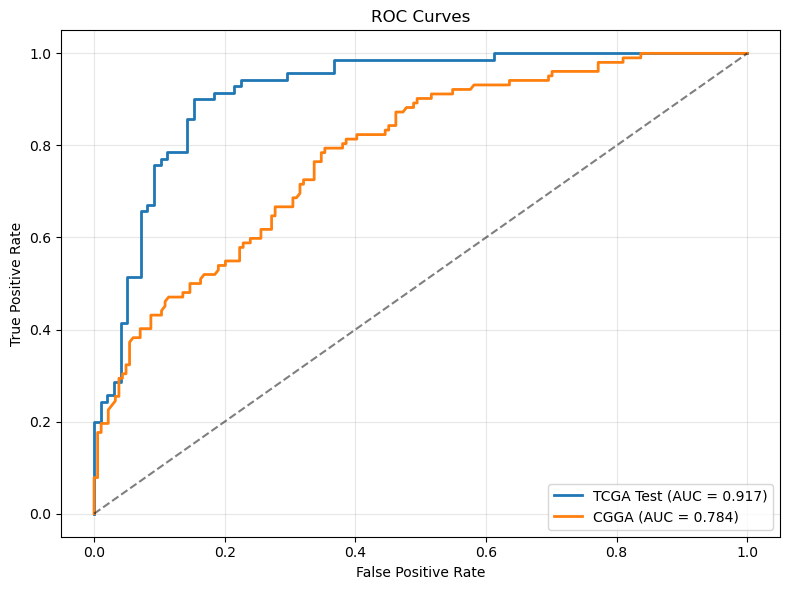

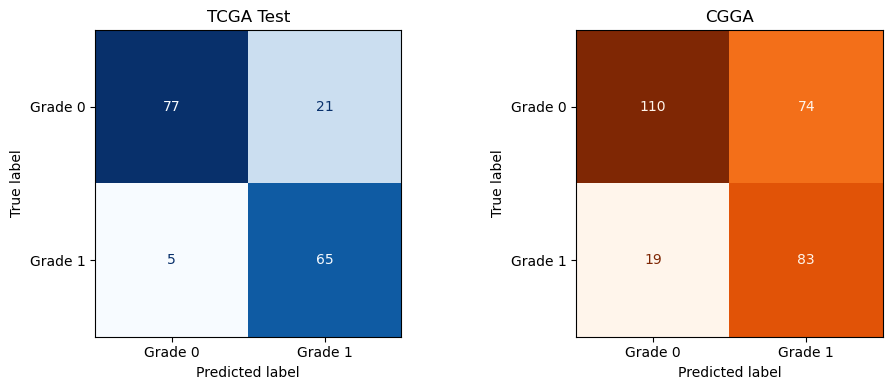

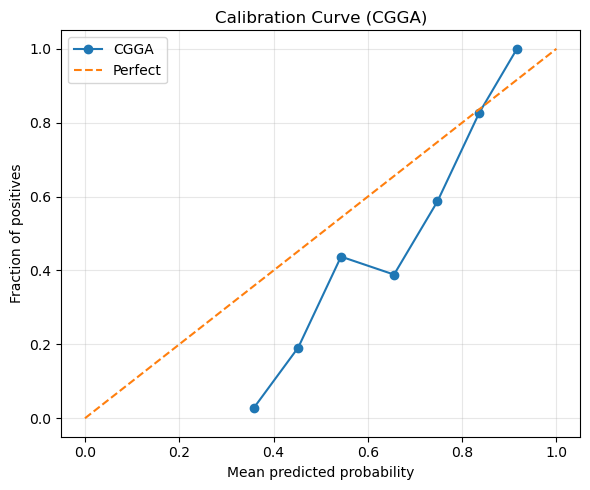

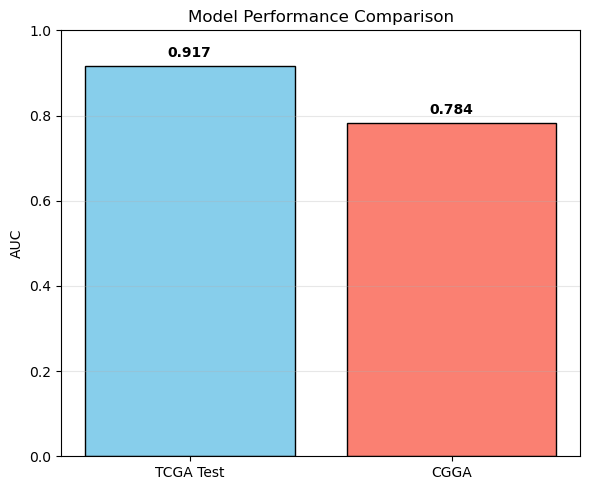

In [30]:
# 11.1 ROC Curves
fpr_test, tpr_test, _ = roc_curve(test_labels, test_probs[:, 1])
fpr_cgga, tpr_cgga, _ = roc_curve(cgga_labels, cgga_probs[:, 1])

plt.figure(figsize=(8,6))
plt.plot(fpr_test, tpr_test, label=f'TCGA Test (AUC = {test_auc:.3f})', linewidth=2)
plt.plot(fpr_cgga, tpr_cgga, label=f'CGGA (AUC = {cgga_auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 11.2 Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10,4))
# TCGA test
cm_test = confusion_matrix(test_labels, test_preds)
disp_test = ConfusionMatrixDisplay(cm_test, display_labels=['Grade 0', 'Grade 1'])
disp_test.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('TCGA Test')
# CGGA
cm_cgga = confusion_matrix(cgga_labels, cgga_preds)
disp_cgga = ConfusionMatrixDisplay(cm_cgga, display_labels=['Grade 0', 'Grade 1'])
disp_cgga.plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('CGGA')
plt.tight_layout()
plt.show()

# 11.3 Calibration Curve (for CGGA)
fraction_positive, mean_predicted = calibration_curve(cgga_labels, cgga_probs[:, 1], n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(mean_predicted, fraction_positive, marker='o', label='CGGA')
plt.plot([0,1], [0,1], '--', label='Perfect')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve (CGGA)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 11.4 AUC Comparison Bar Chart
plt.figure(figsize=(6,5))
bars = plt.bar(['TCGA Test', 'CGGA'], [test_auc, cgga_auc], color=['skyblue', 'salmon'], edgecolor='black')
plt.ylim(0,1)
plt.ylabel('AUC')
plt.title('Model Performance Comparison')
for bar, val in zip(bars, [test_auc, cgga_auc]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:

#12. Save Best Model

#torch.save(best_state, 'trainnedmodels/best_glioma_modelV3.pth')
#print("Model saved.")